In [1]:
#Import the necessary libraries
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

In [2]:
#Create a sample DF - Datetime, Lane, Direction, Class, Rate, Volume, and Revenue
np.random.seed(42)

start_date = datetime(2025, 7, 1)
end_date = datetime(2025, 8, 30)
date_range = pd.date_range(start=start_date, end=end_date, freq='h')

lanes = [f"Lane_{i}" for i in range(1, 23)]
lane_directions = {f"Lane_{i}": "Eastbound" if i <= 11 else "Westbound" for i in range(1, 23)}

vehicle_classes = [2, 3, 4, 5, 6, 7]
weather_conditions = ['Clear', 'Cloudy', 'Rainy', 'Foggy', 'Snowing']

def get_toll_rate(vehicle_class, hour):
    peak = 4 <= hour < 20
    if vehicle_class == 2:
        return 7.80
    elif vehicle_class == 3:
        return 27.20 if peak else 19.50
    elif vehicle_class == 4:
        return 36.30 if peak else 25.90
    elif vehicle_class == 5:
        return 45.40 if peak else 32.40
    elif vehicle_class == 6:
        return 54.40 if peak else 38.90
    else:  # 7 or more axles
        return 63.50 if peak else 45.40

data = []
for dt in date_range:
    for lane in lanes:
        direction = lane_directions[lane]
        for vehicle_class in vehicle_classes:
            volume = np.random.poisson(lam=5 if 4 <= dt.hour < 20 else 2)
            toll_rate = get_toll_rate(vehicle_class, dt.hour)
            revenue = volume * toll_rate
            weather = random.choices(weather_conditions, weights=[50, 20, 15, 10, 5])[0]
            data.append({
                'Datetime': dt,
                'Lane': lane,
                'Direction': direction,
                'VehicleClass': vehicle_class,
                'TollRate': toll_rate,
                'Volume': volume,
                'Weather': weather,
                'Revenue': revenue,
                'DayOfWeek': dt.strftime('%A'),
                'Hour': dt.hour
            })

df = pd.DataFrame(data)

In [3]:
df.head()

,Datetime,Lane,Direction,VehicleClass,TollRate,Volume,Weather,Revenue,DayOfWeek,Hour
0,2025-07-01,Lane_1,Eastbound,2,7.8,4,Clear,31.2,Tuesday,0
1,2025-07-01,Lane_1,Eastbound,3,19.5,1,Clear,19.5,Tuesday,0
2,2025-07-01,Lane_1,Eastbound,4,25.9,3,Foggy,77.7,Tuesday,0
3,2025-07-01,Lane_1,Eastbound,5,32.4,3,Rainy,97.2,Tuesday,0
4,2025-07-01,Lane_1,Eastbound,6,38.9,1,Cloudy,38.9,Tuesday,0


In [4]:
#Daily DF and Hourly DF Aggregation

df["Datetime"] = pd.to_datetime(df["Datetime"])

#Hourly DF
hourly_df = (
    df.groupby("Datetime")[["Volume", "Revenue"]]
    .sum()
    .reset_index()
    )

#Daily DF
daily_df = (
    df.groupby(df["Datetime"].dt.date)[["Volume", "Revenue"]]
    .sum()
    .reset_index()
    .rename(columns={"Datetime": "Date"})
)

#print("Hourly shape:", hourly_df.shape)
#print("Daily shape:", daily_df.shape)

In [5]:
print("Sample Hourly Data:")
hourly_df.head()

Sample Hourly Data:


,Datetime,Volume,Revenue
0,2025-07-01 00:00:00,255,7457.1
1,2025-07-01 01:00:00,254,7473.7
2,2025-07-01 02:00:00,271,7825.4
3,2025-07-01 03:00:00,256,7171.4
4,2025-07-01 04:00:00,662,26441.8


In [6]:
print("Sample Daily Data:")
daily_df.head()

Sample Daily Data:


,Date,Volume,Revenue
0,2025-07-01,12554,468448.8
1,2025-07-02,12882,484462.9
2,2025-07-03,12630,474772.1
3,2025-07-04,12704,471386.5
4,2025-07-05,12816,480713.9


In [7]:
#Import the necessary library
import matplotlib.pyplot as plt

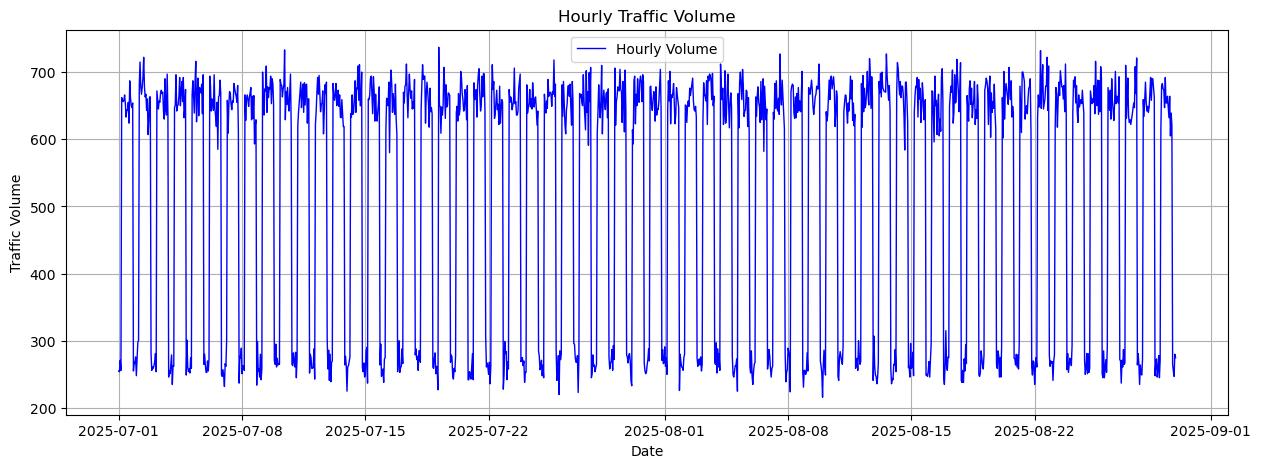

In [8]:
#Hourly Traffic Volume
plt.figure(figsize=(15, 5))
plt.plot(
    hourly_df["Datetime"],
    hourly_df["Volume"],
    label="Hourly Volume",
    color="blue",
    linewidth=1
    )

plt.title("Hourly Traffic Volume")
plt.xlabel("Date")
plt.ylabel("Traffic Volume")
plt.grid()
plt.legend()

plt.show()

In [9]:
#Daily Traffic Volume (Weekday vs. Weekend)

#Add a DayOfWeek/IsWeekend columns
daily_df["Date"] = pd.to_datetime(daily_df["Date"])
daily_df["DayOfWeek"] = daily_df["Date"].dt.day_name()
daily_df["IsWeekend"] = daily_df["DayOfWeek"].isin(["Saturday", "Sunday"])

#daily_df.head()

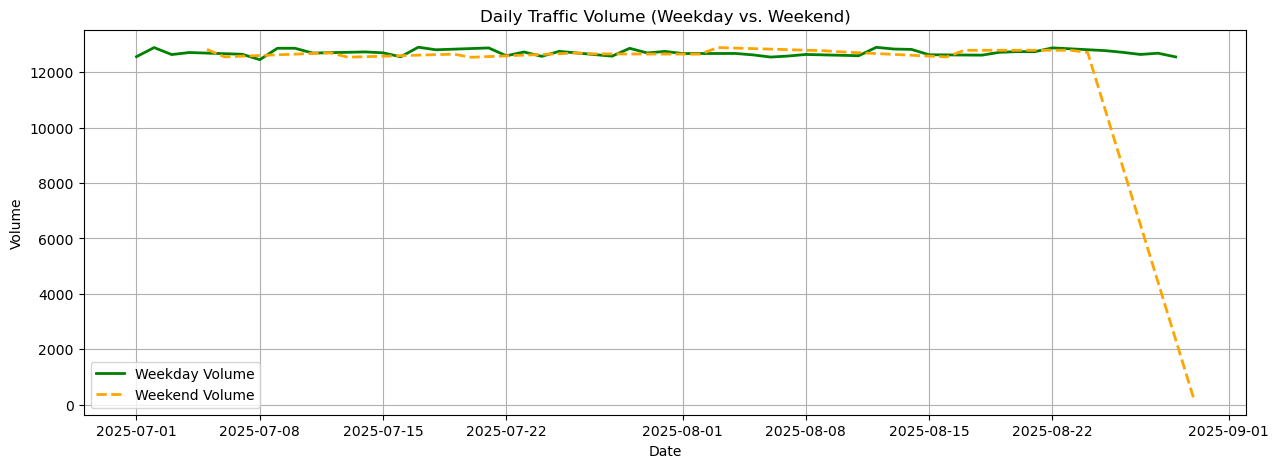

In [10]:
plt.figure(figsize=(15, 5))
plt.plot(daily_df.loc[~daily_df["IsWeekend"], "Date"],
         daily_df.loc[~daily_df["IsWeekend"], "Volume"],
         label="Weekday Volume", color="green", linewidth=2)

plt.plot(daily_df.loc[daily_df["IsWeekend"], "Date"],
         daily_df.loc[daily_df["IsWeekend"], "Volume"],
         label="Weekend Volume", color="orange", linewidth=2, linestyle="--")

plt.title("Daily Traffic Volume (Weekday vs. Weekend)")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.grid()
plt.legend()

plt.show()

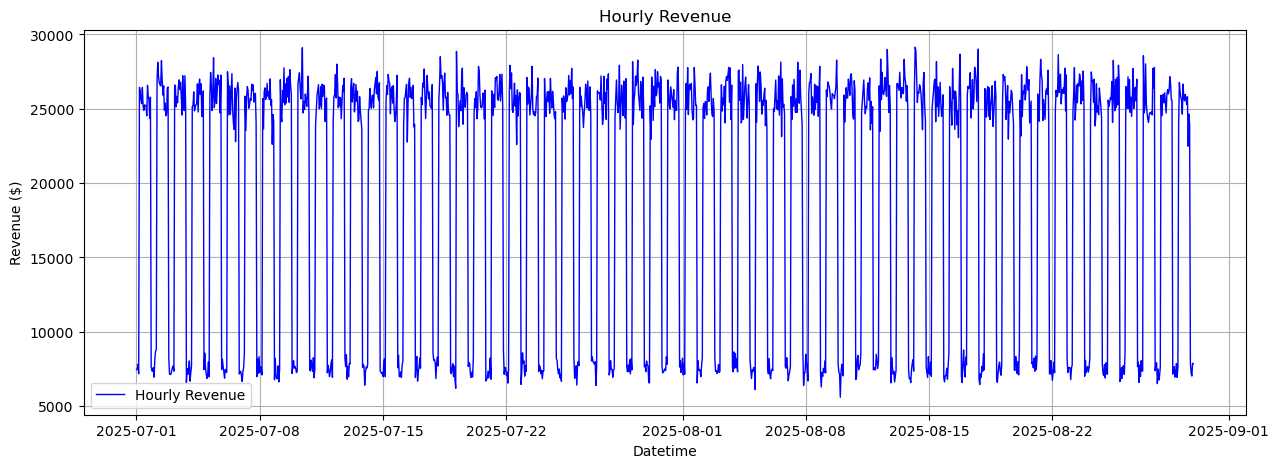

In [11]:
#Hourly Revenue
plt.figure(figsize=(15, 5))
plt.plot(
    hourly_df["Datetime"],
    hourly_df["Revenue"],
    label="Hourly Revenue",
    color="blue",
    linewidth=1
    )
plt.title("Hourly Revenue")
plt.xlabel("Datetime")
plt.ylabel("Revenue ($)")
plt.grid()
plt.legend()

plt.show()

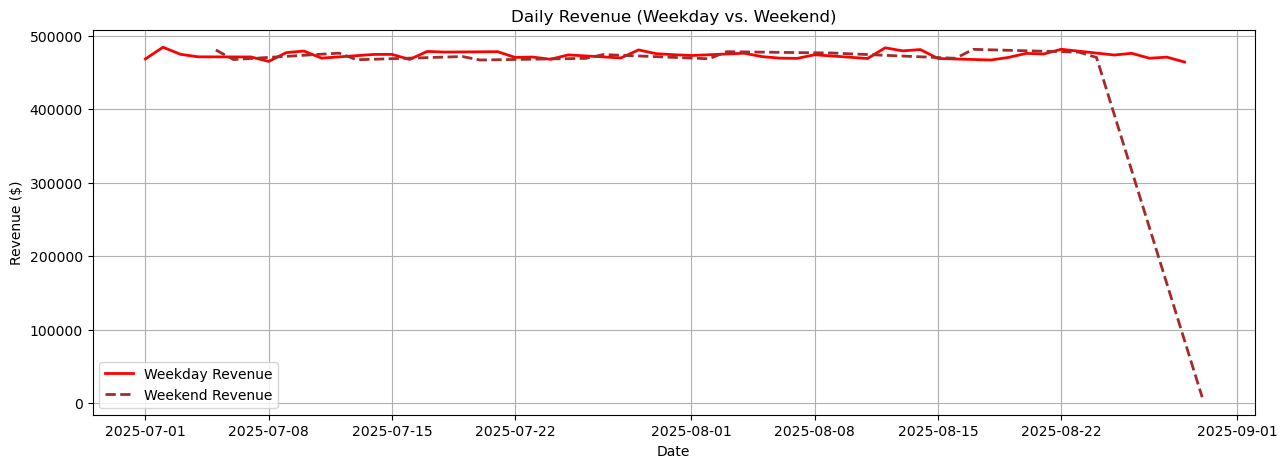

In [12]:
#Daily Revenue (Weekday vs. Weekend)
plt.figure(figsize=(15, 5))
plt.plot(daily_df.loc[~daily_df["IsWeekend"], "Date"],
         daily_df.loc[~daily_df["IsWeekend"], "Revenue"],
         label="Weekday Revenue", color="red", linewidth=2)

plt.plot(daily_df.loc[daily_df["IsWeekend"], "Date"],
         daily_df.loc[daily_df["IsWeekend"], "Revenue"],
         label="Weekend Revenue", color="brown", linewidth=2, linestyle="--")

plt.title("Daily Revenue (Weekday vs. Weekend)")
plt.xlabel("Date")
plt.ylabel("Revenue ($)")
plt.grid()
plt.legend()

plt.show()

In [13]:
#Weekly Aggregation

In [14]:
#Weekly DF
weekly_df = (
    daily_df.set_index("Date")
            .resample("W")[["Volume", "Revenue"]]
            .sum()
            .reset_index()
)

weekly_df.head()

,Date,Volume,Revenue
0,2025-07-06,76134,2847481.6
1,2025-07-13,88715,3306170.2
2,2025-07-20,88844,3312581.5
3,2025-07-27,88831,3305736.4
4,2025-08-03,89057,3320849.3


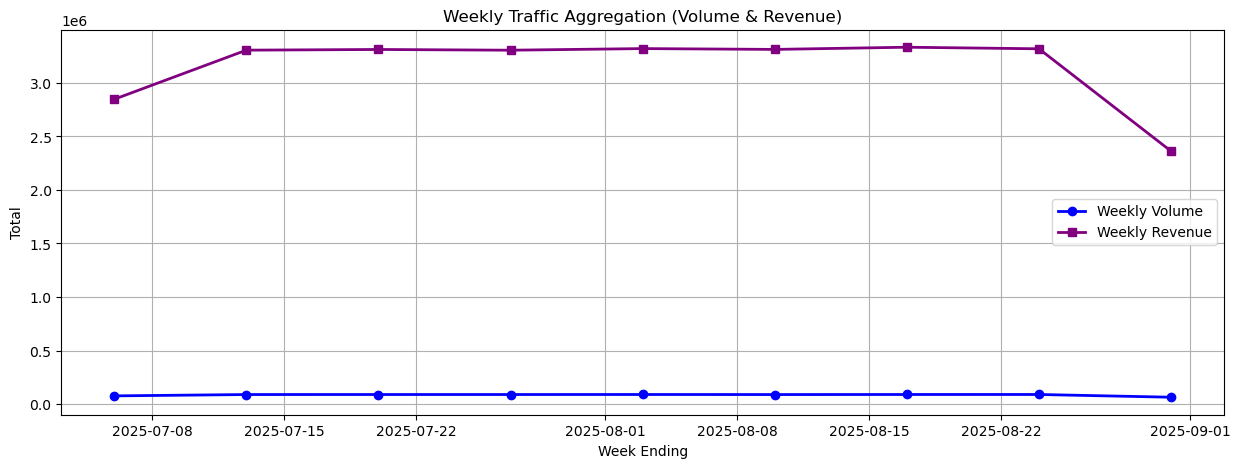

In [15]:
plt.figure(figsize=(15, 5))
plt.plot(
    weekly_df["Date"],
    weekly_df["Volume"],
    label="Weekly Volume",
    color="blue",
    linewidth=2,
    marker="o"
    )
plt.plot(
    weekly_df["Date"],
    weekly_df["Revenue"],
    label="Weekly Revenue",
    color="purple",
    linewidth=2,
    marker="s"
    )
plt.title("Weekly Traffic Aggregation (Volume & Revenue)")
plt.xlabel("Week Ending")
plt.ylabel("Total")
plt.grid()
plt.legend()

plt.show()

In [16]:
#SARIMA Baseline

In [17]:
#Import the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [18]:
daily_df.head()

,Date,Volume,Revenue,DayOfWeek,IsWeekend
0,2025-07-01,12554,468448.8,Tuesday,False
1,2025-07-02,12882,484462.9,Wednesday,False
2,2025-07-03,12630,474772.1,Thursday,False
3,2025-07-04,12704,471386.5,Friday,False
4,2025-07-05,12816,480713.9,Saturday,True


In [19]:
#Target Variable
y = daily_df["Volume"]
#y.head()

In [20]:
#Train-test Split
#Training Dataset - First 3 Wk.'s
train = y[:-7]
#Test Dataset - Last 1 Wk.
test = y[-7:]

In [21]:
#SARIMA Model
sarima_model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
    )

sarima_results = sarima_model.fit(disp=False)
#sarima_results

In [22]:
#Forecaset
forecast = sarima_results.get_forecast(steps=len(test))
pred_mean = forecast.predicted_mean
pred_ci = forecast.conf_int()

#forecast
#pred_mean
#pred_ci

In [23]:
mae = mean_absolute_error(test, pred_mean)
rmse = np.sqrt(mean_squared_error(test, pred_mean))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 1892.38
RMSE: 4677.96


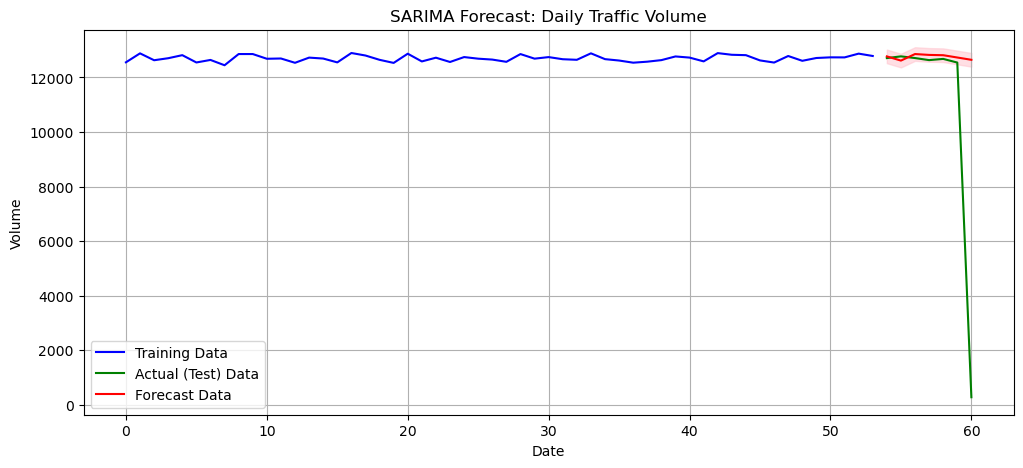

In [24]:
plt.figure(figsize=(12,5))
plt.plot(train.index, train, label="Training Data", color="blue")
plt.plot(test.index, test, label="Actual (Test) Data", color="green")
plt.plot(pred_mean.index, pred_mean, label="Forecast Data", color="red")

# Plot confidence intervals
plt.fill_between(pred_ci.index,
                 pred_ci.iloc[:, 0],
                 pred_ci.iloc[:, 1],
                 color="pink", alpha=0.5)

plt.title("SARIMA Forecast: Daily Traffic Volume")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.legend()
plt.grid()

plt.show()

In [25]:
#Step 3: XGBoost with Lag Features (Machine Learning)

In [26]:
#Import the necessary libraries
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [27]:
df_ml = daily_df.copy()
#df_ml.head()

In [28]:
#Lag Features
df_ml["lag1"] = df_ml["Volume"].shift(1)
df_ml["lag2"] = df_ml["Volume"].shift(2)
df_ml["lag7"] = df_ml["Volume"].shift(7)

#Rolling Mean Features
df_ml["roll3"] = df_ml["Volume"].shift(1).rolling(3).mean()
df_ml["roll7"] = df_ml["Volume"].shift(1).rolling(7).mean()

#Drop null values
df_ml = df_ml.dropna()
#df_ml.head()

#Features/Target
X = df_ml[["lag1", "lag2", "lag7", "roll3", "roll7", "IsWeekend"]]
y = df_ml["Volume"]

X_train, X_test, y_train, y_test = X.iloc[:-7], X.iloc[-7:], y.iloc[:-7], y.iloc[-7:]

In [29]:
#XGBoost Model
model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [30]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")

MAE: 1861.796
RMSE: 4717.825


In [31]:
xgb_results_df = pd.DataFrame({
    "Date": X_test.index,
    "Actual": y_test.values,
    "Forecast": y_pred
}).round(3)

xgb_results_df.head()

,Date,Actual,Forecast
0,54,12709,12663.765625
1,55,12772,12603.857422
2,56,12710,12614.416992
3,57,12634,12574.401367
4,58,12679,12572.066406


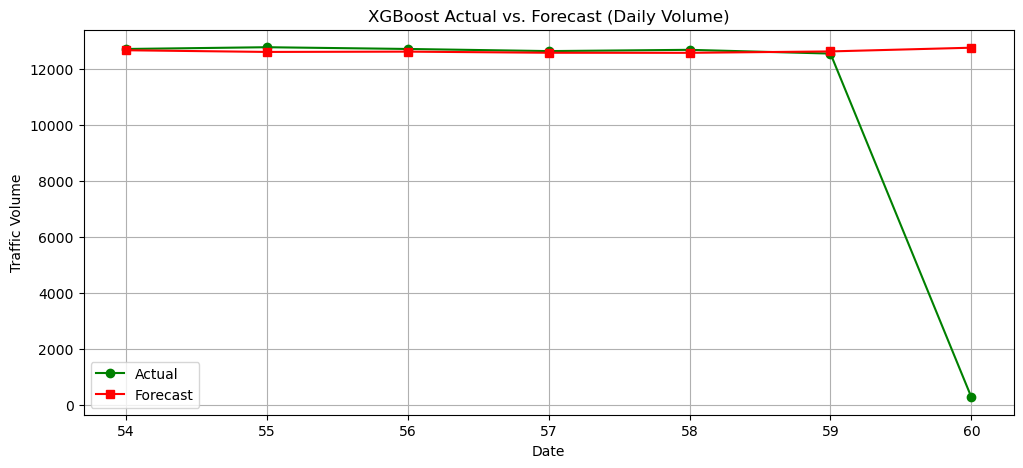

In [32]:
plt.figure(figsize=(12,5))
#Actual Values
plt.plot(
    xgb_results_df["Date"],
    xgb_results_df["Actual"],
    label="Actual",
    color="green",
    marker="o"
    )
#Forecasted Values
plt.plot(
    xgb_results_df["Date"],
    xgb_results_df["Forecast"],
    label="Forecast",
    color="red",
    marker="s"
    )

plt.title("XGBoost Actual vs. Forecast (Daily Volume)")
plt.xlabel("Date")
plt.ylabel("Traffic Volume")
plt.grid()
plt.legend()

plt.show()

In [33]:
#Predict the values for the next 2-3 weeks

In [34]:
df_ml = daily_df.copy()
df_ml.head()

,Date,Volume,Revenue,DayOfWeek,IsWeekend
0,2025-07-01,12554,468448.8,Tuesday,False
1,2025-07-02,12882,484462.9,Wednesday,False
2,2025-07-03,12630,474772.1,Thursday,False
3,2025-07-04,12704,471386.5,Friday,False
4,2025-07-05,12816,480713.9,Saturday,True


In [35]:
#Lag Features
df_ml["lag1"] = df_ml["Volume"].shift(1)
df_ml["lag2"] = df_ml["Volume"].shift(2)
df_ml["lag7"] = df_ml["Volume"].shift(7)

#Rolling Features
df_ml["roll3"] = df_ml["Volume"].shift(1).rolling(3).mean()
df_ml["roll7"] = df_ml["Volume"].shift(1).rolling(7).mean()

#Drop the null values
df_ml = df_ml.dropna()
df_ml.head()

,Date,Volume,Revenue,DayOfWeek,IsWeekend,lag1,lag2,lag7,roll3,roll7
7,2025-07-08,12446,465171.2,Tuesday,False,12641.0,12548.0,12554.0,12668.333333,12682.142857
8,2025-07-09,12857,477094.2,Wednesday,False,12446.0,12641.0,12882.0,12545.000000,12666.714286
9,2025-07-10,12857,479252.4,Thursday,False,12857.0,12446.0,12630.0,12648.000000,12663.142857
10,2025-07-11,12684,469661.4,Friday,False,12857.0,12857.0,12704.0,12720.000000,12695.571429
11,2025-07-12,12694,476402.1,Saturday,True,12684.0,12857.0,12816.0,12799.333333,12692.714286


In [36]:
#Features/Target
X = df_ml[["lag1", "lag2", "lag7", "roll3", "roll7", "IsWeekend"]]
y = df_ml["Volume"]

In [37]:
#XGBoost Model
model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [38]:
import warnings

#Ignore all DeprecationWarnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [39]:
#Import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

HORIZON = 21

#last_date = last_date = daily_df.index.max()
last_date = daily_df["Date"].max()
future_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=HORIZON, freq="D")

vol_series = daily_df["Volume"].copy()

future_rows = []

for dt in future_dates:
    lag1 = vol_series.iloc[-1]
    lag2 = vol_series.iloc[-2]
    lag7 = vol_series.iloc[-7]
    roll3 = vol_series.iloc[-3:].mean()
    roll7 = vol_series.iloc[-7:].mean()
    is_weekend = pd.Timestamp(dt).day_name() in ["Saturday", "Sunday"]

    X_next = pd.DataFrame([{
        "lag1": lag1, "lag2": lag2, "lag7": lag7,
        "roll3": roll3, "roll7": roll7,
        "IsWeekend": is_weekend
    }], index=[dt])

    y_hat = float(model.predict(X_next))

    vol_series.loc[dt] = y_hat

    future_rows.append({
        "Date": dt,
        "Forecast_Volume": y_hat
    })

xgb_future_df = pd.DataFrame(future_rows).set_index("Date").round(3)

#xgb_future_df
xgb_future_df.head()

,Forecast_Volume
Date,
2025-08-31,12697.673
2025-09-01,12676.933
2025-09-02,12651.174
2025-09-03,12723.936
2025-09-04,12689.754


In [40]:
#Import the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

lookback = 21

if "Date" in daily_df.columns:
    daily_idx = daily_df.copy()
    daily_idx["Date"] = pd.to_datetime(daily_idx["Date"])
    daily_idx = daily_idx.set_index("Date")
else:
    daily_idx = daily_df.copy()
    daily_idx.index = pd.to_datetime(daily_idx.index)

actual_tail = (
    daily_idx[["Volume"]]
    .iloc[-lookback:]
    .rename(columns={"Volume": "Actual_Volume"})
)

xgb_future_df = xgb_future_df.copy()
xgb_future_df.index = pd.to_datetime(xgb_future_df.index)

plot_df = actual_tail.join(xgb_future_df, how="outer")
plot_df

,Actual_Volume,Forecast_Volume
Date,,
2025-08-10,12727.0,NaN
2025-08-11,12588.0,NaN
2025-08-12,12891.0,NaN
2025-08-13,12830.0,NaN
2025-08-14,12816.0,NaN
2025-08-15,12623.0,NaN
2025-08-16,12545.0,NaN
2025-08-17,12785.0,NaN
2025-08-18,12609.0,NaN


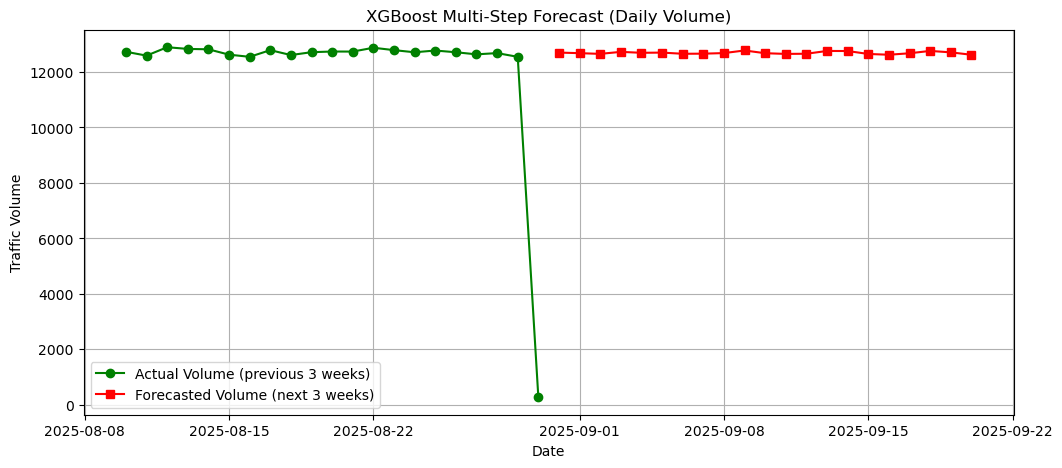

In [41]:
plt.figure(figsize=(12, 5))
plt.plot(
    plot_df.index,
    plot_df["Actual_Volume"],
    label="Actual Volume (previous 3 weeks)",
    color="green",
    marker="o"
    )
plt.plot(
    plot_df.index,
    plot_df["Forecast_Volume"],
    label="Forecasted Volume (next 3 weeks)",
    color="red",
    marker="s"
    )
plt.title("XGBoost Multi-Step Forecast (Daily Volume)")
plt.xlabel("Date")
plt.ylabel("Traffic Volume")
plt.grid()
plt.legend()

plt.show()

In [42]:
#Step 4: LSTM (Deep Learning)

In [43]:
daily_df.head()

,Date,Volume,Revenue,DayOfWeek,IsWeekend
0,2025-07-01,12554,468448.8,Tuesday,False
1,2025-07-02,12882,484462.9,Wednesday,False
2,2025-07-03,12630,474772.1,Thursday,False
3,2025-07-04,12704,471386.5,Friday,False
4,2025-07-05,12816,480713.9,Saturday,True


In [44]:
#Import the necessary libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
#Target Series
series = daily_df["Volume"].values.reshape(-1, 1)

#Normalize
scaler = MinMaxScaler()
scaled_series = scaler.fit_transform(series)

In [ ]:
#Build Sequences
def create_sequences(data, seq_length=7):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)


#Past 21 days to predict the next day
#Note: The larger variability, the more accurate the model is going to be
SEQ_LEN = 21
X, y = create_sequences(scaled_series, SEQ_LEN)

#Train/Test Split
split = -21
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
#LSTM Model
model = Sequential([
    LSTM(64, activation="tanh", input_shape=(SEQ_LEN, 1)),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")

#Train the Model
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
    )

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 220ms/step - loss: 0.6981 - val_loss: 0.4501
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.4526 - val_loss: 0.2474
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.2356 - val_loss: 0.0965
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.0692 - val_loss: 0.0457
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.0021 - val_loss: 0.1271
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0619 - val_loss: 0.1540
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0799 - val_loss: 0.1005
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.0353 - val_loss: 0.0574
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.0045 - val_loss: 0.0443
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 0.0013 - val_loss: 0.0468
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0098 - val_loss: 0.0515
Epoch 12/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0173 - val_loss: 0.0527
Epoch 13

In [ ]:
y_pred_scaled = model.predict(X_test)

y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1))
y_pred_inv = scaler.inverse_transform(y_pred_scaled)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step


In [ ]:
date_col = pd.to_datetime(daily_df["Date"])
date_values = date_col[-len(y_test):].values

lstm_results_df = pd.DataFrame({
    "Date": date_values,
    "Actual": y_test_inv.flatten(),
    "Forecast": y_pred_inv.flatten()
}).round(3)

lstm_results_df

,Date,Actual,Forecast
0,2025-08-10,12727.0,12617.842773
1,2025-08-11,12588.0,12621.717773
2,2025-08-12,12891.0,12614.674805
3,2025-08-13,12830.0,12632.333008
4,2025-08-14,12816.0,12644.583984
5,2025-08-15,12623.0,12656.825195
6,2025-08-16,12545.0,12652.716797
7,2025-08-17,12785.0,12641.509766
8,2025-08-18,12609.0,12647.632812
9,2025-08-19,12712.0,12639.660156


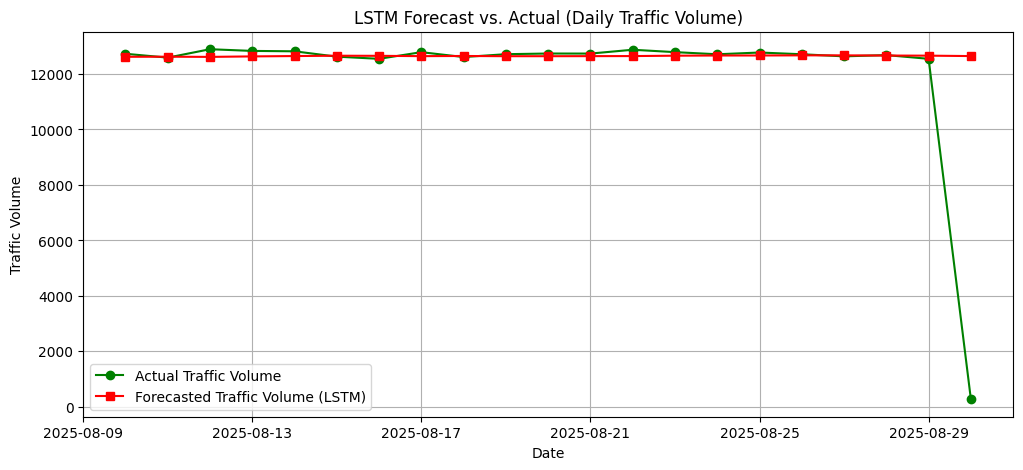

In [ ]:
#Import the necessary library
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(
    lstm_results_df["Date"],
    lstm_results_df["Actual"],
    label="Actual Traffic Volume",
    color="green",
    marker="o")
plt.plot(
    lstm_results_df["Date"],
    lstm_results_df["Forecast"],
    label="Forecasted Traffic Volume (LSTM)",
    color="red",
    marker="s"
    )
plt.title("LSTM Forecast vs. Actual (Daily Traffic Volume)")
plt.xlabel("Date")
plt.ylabel("Traffic Volume")
plt.legend()
plt.grid()

plt.show()

In [ ]:
'''
last_actual_date = actual_tail["Date"].max()
last_actual_date
'''

'\nlast_actual_date = actual_tail["Date"].max()\nlast_actual_date\n'

In [ ]:
'''
#Previous 21 Days (3 Wk.'s)
LOOKBACK = 21
actual_tail = (
    daily_df[["Date", "Volume"]]
    .tail(LOOKBACK)
    .rename(columns={"Volume": "Actual_Volume"})
)

#Future 21 days (3 Wk. Forecast)
HORIZON = 21
last_actual_date = actual_tail["Date"].max()

lstm_future_df = pd.DataFrame({
    "Date": future_dates,
    "Forecast_Volume": future_values
}).round(3)

lstm_future_df = lstm_future_df[lstm_future_df["Date"] > last_actual_date]

lstm_actuals_and_future = (
    pd.concat([actual_tail, lstm_future_df], ignore_index=True)
    .round(3)
)

#Table
lstm_actuals_and_future
'''

'\n#Previous 21 Days (3 Wk.\'s)\nLOOKBACK = 21\nactual_tail = (\n    daily_df[["Date", "Volume"]]\n    .tail(LOOKBACK)\n    .rename(columns={"Volume": "Actual_Volume"})\n)\n\n#Future 21 days (3 Wk. Forecast)\nHORIZON = 21\nlast_actual_date = actual_tail["Date"].max()\n\nlstm_future_df = pd.DataFrame({\n    "Date": future_dates,\n    "Forecast_Volume": future_values\n}).round(3)\n\nlstm_future_df = lstm_future_df[lstm_future_df["Date"] > last_actual_date]\n\nlstm_actuals_and_future = (\n    pd.concat([actual_tail, lstm_future_df], ignore_index=True)\n    .round(3)\n)\n\n#Table\nlstm_actuals_and_future\n'

In [ ]:
#Future 21 days (3 Wk. Forecast)
HORIZON = 21

last_actual_date = pd.to_datetime(daily_df["Date"]).max()

future_dates = pd.date_range(
    start=last_actual_date + pd.Timedelta(days=1),
    periods=HORIZON,
    freq="D"
)

last_window = scaled_series[-SEQ_LEN:].copy()
future_scaled = []

for _ in range(HORIZON):
    x_in = last_window.reshape(1, SEQ_LEN, 1)
    yhat_scaled = model.predict(x_in, verbose=0)
    future_scaled.append(yhat_scaled.item())
    last_window = np.vstack([last_window[1:], yhat_scaled])

future_values = scaler.inverse_transform(
    np.array(future_scaled).reshape(-1, 1)
).flatten()

lstm_future_df = pd.DataFrame({
    "Date": future_dates,
    "Forecast_Volume": future_values
}).round(3)

#Previous 21 Days (3 Wk.'s)
LOOKBACK = 21
actual_tail = (
    daily_df[["Date", "Volume"]]
    .tail(LOOKBACK)
    .rename(columns={"Volume": "Actual_Volume"})
)

lstm_future_df = lstm_future_df[lstm_future_df["Date"] > actual_tail["Date"].max()]

lstm_actuals_and_future = (
    pd.concat([actual_tail, lstm_future_df], ignore_index=True)
    .round(3)
)

lstm_actuals_and_future

,Date,Actual_Volume,Forecast_Volume
0,2025-08-10,12727.0,NaN
1,2025-08-11,12588.0,NaN
2,2025-08-12,12891.0,NaN
3,2025-08-13,12830.0,NaN
4,2025-08-14,12816.0,NaN
5,2025-08-15,12623.0,NaN
6,2025-08-16,12545.0,NaN
7,2025-08-17,12785.0,NaN
8,2025-08-18,12609.0,NaN
9,2025-08-19,12712.0,NaN


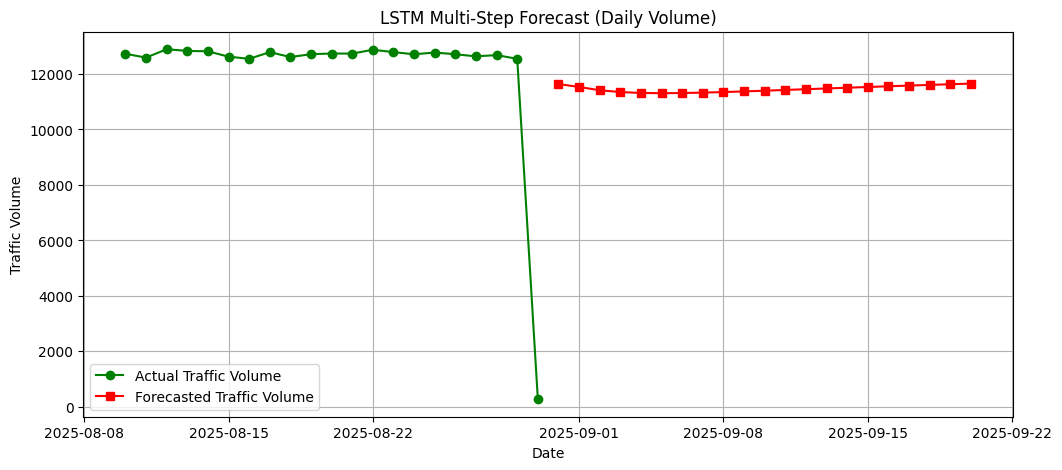

In [ ]:
#Import the necessary library
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

#Actual Volume
plt.plot(
    lstm_actuals_and_future["Date"],
    lstm_actuals_and_future["Actual_Volume"],
    label="Actual Traffic Volume",
    color="green",
    marker="o"
)

#Forecasted Volume
plt.plot(
    lstm_actuals_and_future["Date"],
    lstm_actuals_and_future["Forecast_Volume"],
    label="Forecasted Traffic Volume",
    color="red",
    marker="s"
)

plt.title("LSTM Multi-Step Forecast (Daily Volume)")
plt.xlabel("Date")
plt.ylabel("Traffic Volume")
plt.grid()
plt.legend()

plt.show()

In [ ]:
#Model that will be used for Analysis: XGBOOST

In [ ]:
import warnings

#Ignore all DeprecationWarnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [ ]:
#Import the necessary libraries
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [ ]:
df_ml = daily_df.copy()
#df_ml.head()

#Lag Features
df_ml["lag1"] = df_ml["Volume"].shift(1)
df_ml["lag2"] = df_ml["Volume"].shift(2)
df_ml["lag7"] = df_ml["Volume"].shift(7)

#Rolling Features
df_ml["roll3"] = df_ml["Volume"].shift(1).rolling(3).mean()
df_ml["roll7"] = df_ml["Volume"].shift(1).rolling(7).mean()

#Drop the null values
df_ml = df_ml.dropna()
#df_ml.head()

#Features/Target
X = df_ml[["lag1", "lag2", "lag7", "roll3", "roll7", "IsWeekend"]]
y = df_ml["Volume"]

#Train-Test Split
X_train, X_test, y_train, y_test = X.iloc[:-7], X.iloc[-7:], y.iloc[:-7], y.iloc[-7:]

In [ ]:
#XGBoost Model
model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
#Import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Future 21 Days
HORIZON = 21

#last_date = last_date = daily_df.index.max()
last_date = daily_df["Date"].max()
future_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=HORIZON, freq="D")

vol_series = daily_df["Volume"].copy()

future_rows = []

for dt in future_dates:
    lag1 = vol_series.iloc[-1]
    lag2 = vol_series.iloc[-2]
    lag7 = vol_series.iloc[-7]
    roll3 = vol_series.iloc[-3:].mean()
    roll7 = vol_series.iloc[-7:].mean()
    is_weekend = pd.Timestamp(dt).day_name() in ["Saturday", "Sunday"]

    X_next = pd.DataFrame([{
        "lag1": lag1, "lag2": lag2, "lag7": lag7,
        "roll3": roll3, "roll7": roll7,
        "IsWeekend": is_weekend
    }], index=[dt])

    y_hat = float(model.predict(X_next))

    vol_series.loc[dt] = y_hat

    future_rows.append({
        "Date": dt,
        "Forecast_Volume": y_hat
    })

xgb_future_df = pd.DataFrame(future_rows).set_index("Date").round(3)

#xgb_future_df
#xgb_future_df.head()

#Past 21 Days
lookback = 21

if "Date" in daily_df.columns:
    daily_idx = daily_df.copy()
    daily_idx["Date"] = pd.to_datetime(daily_idx["Date"])
    daily_idx = daily_idx.set_index("Date")
else:
    daily_idx = daily_df.copy()
    daily_idx.index = pd.to_datetime(daily_idx.index)

actual_tail = (
    daily_idx[["Volume"]]
    .iloc[-lookback:]
    .rename(columns={"Volume": "Actual_Volume"})
)

xgb_future_df = xgb_future_df.copy()
xgb_future_df.index = pd.to_datetime(xgb_future_df.index)

plot_df = actual_tail.join(xgb_future_df, how="outer")
plot_df

,Actual_Volume,Forecast_Volume
Date,,
2025-08-10,12727.0,NaN
2025-08-11,12588.0,NaN
2025-08-12,12891.0,NaN
2025-08-13,12830.0,NaN
2025-08-14,12816.0,NaN
2025-08-15,12623.0,NaN
2025-08-16,12545.0,NaN
2025-08-17,12785.0,NaN
2025-08-18,12609.0,NaN


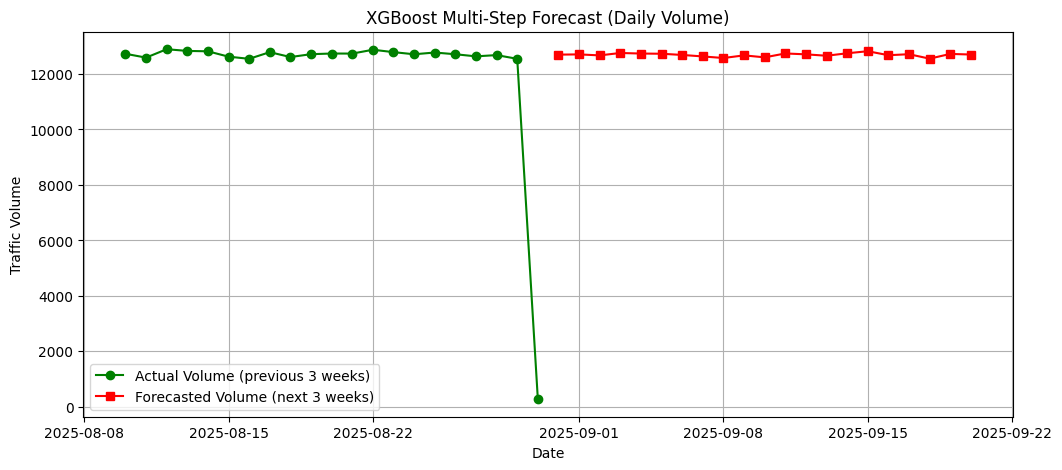

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(
    plot_df.index,
    plot_df["Actual_Volume"],
    label="Actual Volume (previous 3 weeks)",
    color="green",
    marker="o"
    )
plt.plot(
    plot_df.index,
    plot_df["Forecast_Volume"],
    label="Forecasted Volume (next 3 weeks)",
    color="red",
    marker="s"
    )
plt.title("XGBoost Multi-Step Forecast (Daily Volume)")
plt.xlabel("Date")
plt.ylabel("Traffic Volume")
plt.grid()
plt.legend()

plt.show()

In [45]:
#TDL: Work on the XGBOOST Model